# Text cleaning and Sentiment

## 1. Import Libraries

This section imports the libraries needed for text cleaning, feature extraction, sentiment analysis and saving outputs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

## 2. Load Cleaned Dataset

We load the cleaned NVIDIA tweets dataset created in Notebook 1.

In [ ]:
df = pd.read_csv("../data/processed/nvidia_tweets_cleaned.csv")

df.head()

,Datetime,Tweet Id,Text,Username,date
0,2023-02-06 10:07:17+00:00,1.622537e+18,$nvda Top analyst price target for next week ...,RyderJohnston6,2023-02-06
1,2023-02-06 10:06:30+00:00,1.622537e+18,$nvda Top analyst price target for this week.🔗...,k_mebane,2023-02-06
2,2023-02-06 10:06:08+00:00,1.622537e+18,$nvda Top analyst price target for next week.....,RonaldBevan2,2023-02-06
3,2023-02-06 10:05:43+00:00,1.622537e+18,$NVDA Top analyst target price for next week🚀 ...,Eva077777,2023-02-06
4,2023-02-06 10:03:49+00:00,1.622537e+18,$rsls rebound 🚨🚨🚀🚀🚀\n————\n\n$EDSA\n$KODK\n$DO...,MrBlackTrading,2023-02-06


In [ ]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (99633, 5)
Columns: ['Datetime', 'Tweet Id', 'Text', 'Username', 'date']


## 3. Prepare Date Column

We make sure the Datetime column is in the correct format for daily sentiment analysis.

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df['date'] = df['Datetime'].dt.date

df[['Datetime', 'date']].head()

,Datetime,date
0,2023-02-06 10:07:17+00:00,2023-02-06
1,2023-02-06 10:06:30+00:00,2023-02-06
2,2023-02-06 10:06:08+00:00,2023-02-06
3,2023-02-06 10:05:43+00:00,2023-02-06
4,2023-02-06 10:03:49+00:00,2023-02-06


## 4. Text Length

We create simple text length features to understand the size of the tweets before text cleaning.

In [ ]:
df['text_length'] = df['Text'].astype(str).apply(len)
df['word_count'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

df[['Text', 'text_length', 'word_count']].head()

,Text,text_length,word_count
0,$nvda Top analyst price target for next week ...,74,10
1,$nvda Top analyst price target for this week.🔗...,74,10
2,$nvda Top analyst price target for next week.....,73,9
3,$NVDA Top analyst target price for next week🚀 ...,69,9
4,$rsls rebound 🚨🚨🚀🚀🚀\n————\n\n$EDSA\n$KODK\n$DO...,129,22


In [ ]:
print("Average text length:", df['text_length'].mean())
print("Average word count:", df['word_count'].mean())
print("Maximum word count:", df['word_count'].max())

Average text length: 171.3676492728313
Average word count: 25.904429255367198
Maximum word count: 96


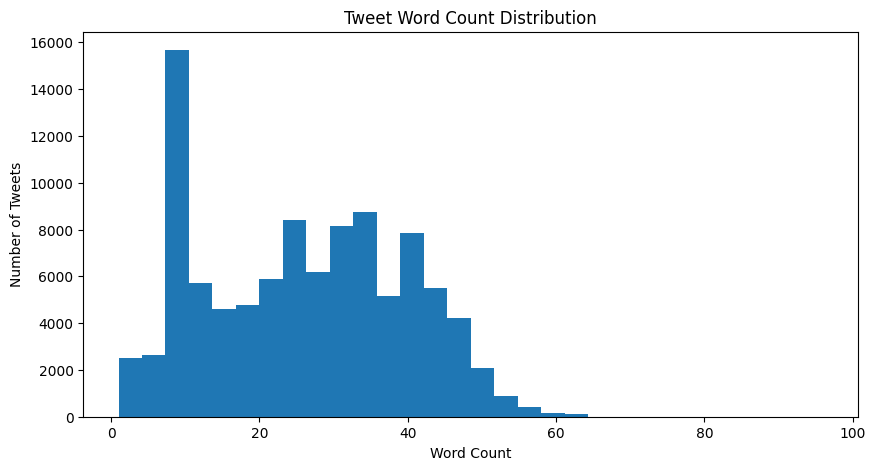

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=30)
plt.title("Tweet Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Tweets")
plt.show()

## 5. Clean Tweet Text

We clean the tweet text by converting it to lowercase and removing URLs, mentions, hashtags symbols, cashtags, punctuation, numbers and extra spaces. 

In [ ]:
def clean_tweet_text(text):
    text = str(text).lower()
    
    #remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    #remove mentions
    text = re.sub(r"@\w+", "", text)
    #remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)
    #remove dollar sign from cashtags but keep the stock symbol
    text = re.sub(r"\$", "", text)
    #remove punctuation, numbers, emojis, and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    #remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['clean_text'] = df['Text'].apply(clean_tweet_text)

df[['Text', 'clean_text']].head()

,Text,clean_text
0,$nvda Top analyst price target for next week ...,nvda top analyst price target for next week
1,$nvda Top analyst price target for this week.🔗...,nvda top analyst price target for this week
2,$nvda Top analyst price target for next week.....,nvda top analyst price target for next week
3,$NVDA Top analyst target price for next week🚀 ...,nvda top analyst target price for next week
4,$rsls rebound 🚨🚨🚀🚀🚀\n————\n\n$EDSA\n$KODK\n$DO...,rsls rebound edsa kodk dow gnus idex bsbs tsla...


## 6. Extract Hashtags, Mentions and Cashtags

These are kept separately because they can be useful for topic analysis and network analysis later.

In [ ]:
def extract_hashtags(text):
    return re.findall(r"#\w+", str(text).lower())

def extract_mentions(text):
    return re.findall(r"@\w+", str(text).lower())

def extract_cashtags(text):
    return re.findall(r"\$[A-Za-z]+", str(text).upper())

df['hashtags'] = df['Text'].apply(extract_hashtags)
df['mentions'] = df['Text'].apply(extract_mentions)
df['cashtags'] = df['Text'].apply(extract_cashtags)

df[['Text', 'hashtags', 'mentions', 'cashtags']].head()

,Text,hashtags,mentions,cashtags
0,$nvda Top analyst price target for next week ...,[],[],[$NVDA]
1,$nvda Top analyst price target for this week.🔗...,[],[],[$NVDA]
2,$nvda Top analyst price target for next week.....,[],[],[$NVDA]
3,$NVDA Top analyst target price for next week🚀 ...,[],[],[$NVDA]
4,$rsls rebound 🚨🚨🚀🚀🚀\n————\n\n$EDSA\n$KODK\n$DO...,[],[],"[$RSLS, $EDSA, $KODK, $DOW, $GNUS, $IDEX, $BSB..."


## 7. Count Hashtags

We count the most common hashtags in the NVIDIA tweet dataset

In [ ]:
all_hashtags = []

for tags in df['hashtags']:
    all_hashtags.extend(tags)

hashtag_counts = pd.Series(all_hashtags).value_counts()

hashtag_counts.head(20)

#stocks            3097
#stockmarket       1594
#investing         1498
#trading           1345
#daytrading         941
#optionstrading     900
#options            864
#stock              765
#investment         665
#nasdaq             628
#satisfied          598
#manufacturing      571
#winner             570
#bitcoin            564
#investor           551
#technology         535
#mwn                513
#wsb                509
#stockstowatch      501
#nvda               500
Name: count, dtype: int64

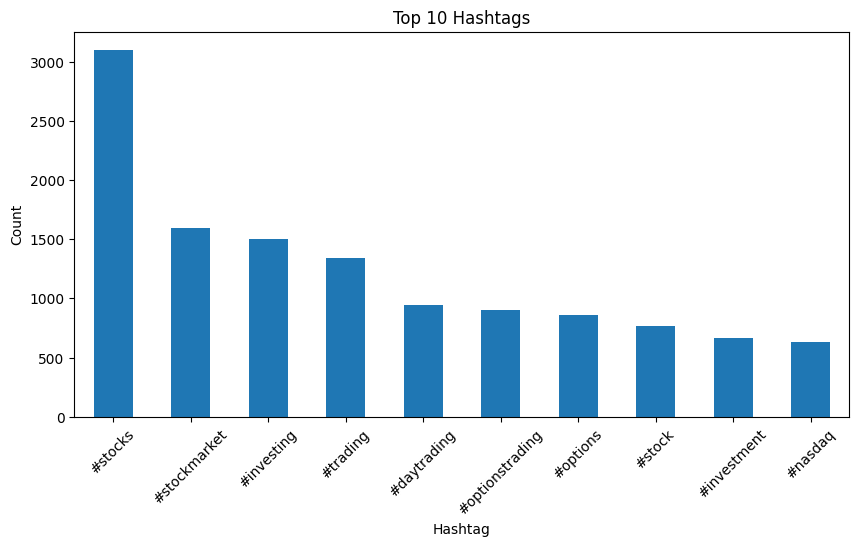

In [ ]:
plt.figure(figsize=(10, 5))
hashtag_counts.head(10).plot(kind='bar')
plt.title("Top 10 Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 8. Count Mentions

This section counts the most common mentioned users in the NVIDIA tweets dataset.

In [ ]:
all_mentions = []

for mentions in df['mentions']:
    all_mentions.extend(mentions)

mention_counts = pd.Series(all_mentions).value_counts()

mention_counts.head(20)

@marketwirenews     529
@ajtrader7          192
@youtube            138
@unusual_whales     136
@chazzsheen3        132
@eliant_capital     121
@trevelfund         109
@jimcramer          100
@elonmusk            87
@trendspider         71
@profitstaken        70
@marketrebels        67
@hellsbellsbbs       66
@benderprofitbox     66
@nvidia              66
@mr_derivatives      66
@the_rocktrading     65
@bulitrades          62
@gambistefinance     61
@breakoutstocks      59
Name: count, dtype: int64

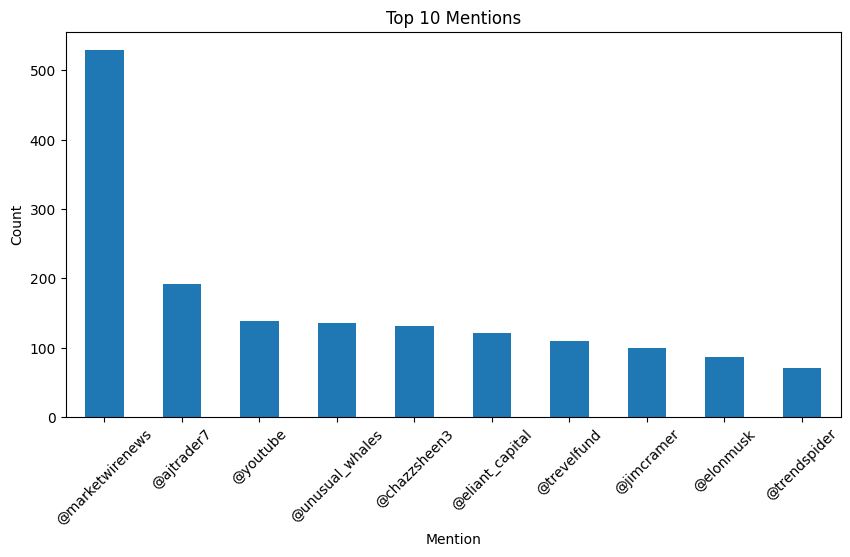

In [ ]:
plt.figure(figsize=(10, 5))
mention_counts.head(10).plot(kind='bar')
plt.title("Top 10 Mentions")
plt.xlabel("Mention")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 9. Count Cashtags

This section counts the most common cashtags such as $NVDA in the NVIDIA tweets dataset.

In [ ]:
all_cashtags = []

for cashtags in df['cashtags']:
    all_cashtags.extend(cashtags)

cashtag_counts = pd.Series(all_cashtags).value_counts()

cashtag_counts.head(20)

$NVDA    100858
$TSLA     48810
$SPY      38615
$AAPL     38114
$AMZN     34507
$AMD      29294
$QQQ      22384
$NFLX     20973
$BABA     20342
$BA       19203
$MSFT     18396
$ROKU     16671
$FB       15181
$SHOP     12944
$SPX      10286
$AMC       8921
$INTC      7991
$DAL       7794
$EBAY      7738
$TWTR      7696
Name: count, dtype: int64

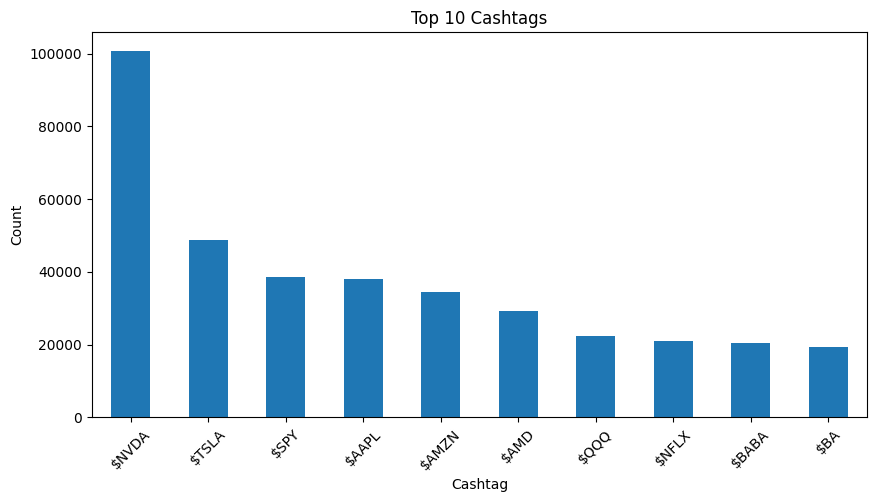

In [ ]:
plt.figure(figsize=(10, 5))
cashtag_counts.head(10).plot(kind='bar')
plt.title("Top 10 Cashtags")
plt.xlabel("Cashtag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 10. Apply VADER Sentiment Analysis

We apply VADER sentiment analysis to the cleaned tweet text. 

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [ ]:
df['compound_score'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df[['clean_text', 'compound_score']].head()

,clean_text,compound_score
0,nvda top analyst price target for next week,0.2023
1,nvda top analyst price target for this week,0.2023
2,nvda top analyst price target for next week,0.2023
3,nvda top analyst target price for next week,0.2023
4,rsls rebound edsa kodk dow gnus idex bsbs tsla...,0.0000


## 11. Create Sentiment Labels

This section converts the VADER compound score into three sentiment labels: positive, neutral and negative.

In [ ]:
def get_sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df['sentiment'] = df['compound_score'].apply(get_sentiment_label)

df[['clean_text', 'compound_score', 'sentiment']].head()

,clean_text,compound_score,sentiment
0,nvda top analyst price target for next week,0.2023,positive
1,nvda top analyst price target for this week,0.2023,positive
2,nvda top analyst price target for next week,0.2023,positive
3,nvda top analyst target price for next week,0.2023,positive
4,rsls rebound edsa kodk dow gnus idex bsbs tsla...,0.0000,neutral


In [ ]:
df['sentiment'].value_counts()

sentiment
positive    56981
neutral     30472
negative    12180
Name: count, dtype: int64

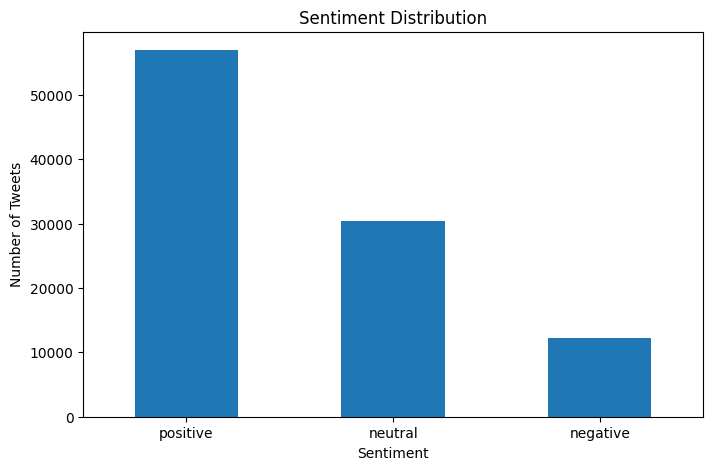

In [ ]:
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.show()

## 12. Daily Sentiment Summary

We group tweets by date to calculate daily tweet volume and average sentiment which will be useful later when comparing tweet activity and sentiment with NVIDIA stock price movement.

In [ ]:
daily_sentiment = df.groupby('date').agg(
    tweet_count=('Text', 'count'),
    average_sentiment=('compound_score', 'mean'),
    positive_count=('sentiment', lambda x: (x == 'positive').sum()),
    neutral_count=('sentiment', lambda x: (x == 'neutral').sum()),
    negative_count=('sentiment', lambda x: (x == 'negative').sum())
).reset_index()

daily_sentiment.head()

,date,tweet_count,average_sentiment,positive_count,neutral_count,negative_count
0,2022-11-21,661,0.212901,335,227,99
1,2022-11-22,1411,0.214759,751,514,146
2,2022-11-23,1189,0.235317,622,460,107
3,2022-11-24,876,0.252928,516,266,94
4,2022-11-25,781,0.235235,441,256,84


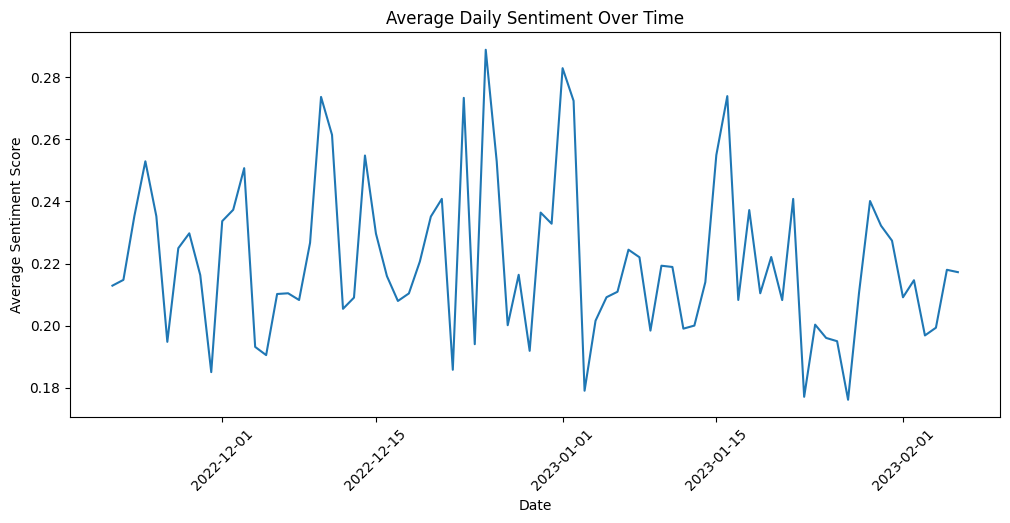

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sentiment['date'], daily_sentiment['average_sentiment'])
plt.title("Average Daily Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=45)
plt.show()

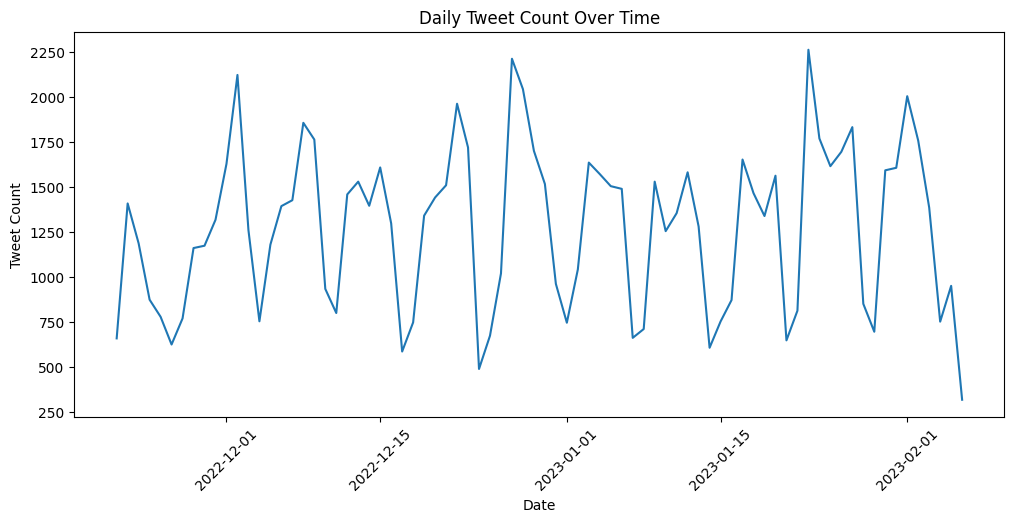

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sentiment['date'], daily_sentiment['tweet_count'])
plt.title("Daily Tweet Count Over Time")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.xticks(rotation=45)
plt.show()

## 13. Save full processed dataset, daily sentiment summary, hashtag, mentions and cashtag.


In [ ]:
os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/nvidia_tweets_sentiment_processed.csv", index=False)

print("Processed sentiment dataset saved to ../data/processed/nvidia_tweets_sentiment_processed.csv")

Processed sentiment dataset saved to ../data/processed/nvidia_tweets_sentiment_processed.csv


In [ ]:
daily_sentiment.to_csv("../data/processed/nvidia_daily_sentiment.csv", index=False)

print("Daily sentiment summary saved to ../data/processed/nvidia_daily_sentiment.csv")

Daily sentiment summary saved to ../data/processed/nvidia_daily_sentiment.csv


In [ ]:
hashtags_df = hashtag_counts.reset_index()
hashtags_df.columns = ['hashtag', 'count']

mentions_df = mention_counts.reset_index()
mentions_df.columns = ['mention', 'count']

cashtags_df = cashtag_counts.reset_index()
cashtags_df.columns = ['cashtag', 'count']

hashtags_df.to_csv("../data/processed/nvidia_hashtags.csv", index=False)
mentions_df.to_csv("../data/processed/nvidia_mentions.csv", index=False)
cashtags_df.to_csv("../data/processed/nvidia_cashtags.csv", index=False)

print("Hashtags, mentions, and cashtags saved.")

Hashtags, mentions, and cashtags saved.
